# Project 1: Approximations

Add of the imports below

In [2]:
import numpy as np
import matplotlib.pyplot as plt 

## Exercise 1

Assume
$$f(x) = \frac{1}{e^{x^2}}$$

Plot the loglog of the error of the 3 different approximations of the derivative of `f` at the point `x=1` as a function of `h` where `h` is in the range `[10^{-1}, 10^{-2},10^{-3},10^{-4}]`.   

What is the slope of each of the 3 approximations? Which one is the best?




In [3]:
# This function take an integer (x) as an argument and returns a float of 1/ e**(-x**2)
def f(x: int) -> float :
    return np.exp(-x**2)     

In [4]:
#  This function returns the value of the derivative of f(x)
def f_prime(x: int) -> float : 
    return -2 * x * np.exp(-x**2)

In [5]:
# The derivative of f(x) at x = 1 
x0: int = 1
derivative_x0 = f_prime(x0)

# H-values from the range described 
h_values = np.array([0.1/(10**i) for i in range (4)])

In [6]:
# Creating empty lists to store the errors 
errors_right = []
errors_left = []
errors_center = []

# Compute approximations using right/left/center formulas and the H-values
for h in h_values:
    right = (f(x0 + h) - f(x0)) / h
    left = (f(x0) - f(x0 - h)) / h
    center = (f(x0 + h) - f(x0 - h)) / (2*h)
# Storing the different errors as h changes. The errors are computed by finding the absolute value of the subtraction of the actual derivative value from the approximations 
    errors_right.append(abs(right - derivative_x0))
    errors_left.append(abs(left - derivative_x0))
    errors_center.append(abs(center - derivative_x0))

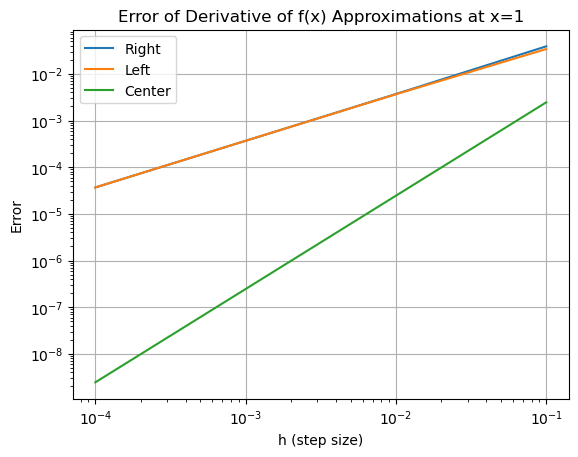

In [7]:
# Plot log-log graph
plt.loglog(h_values, errors_right, label="Right")
plt.loglog(h_values, errors_left, label="Left")
plt.loglog(h_values, errors_center, label="Center")

plt.xlabel("h (step size)")
plt.ylabel("Error")
plt.title("Error of Derivative of f(x) Approximations at x=1")
plt.legend()
plt.grid (True)
plt.show()

In [8]:
# Convert to arrays
errors_right = np.array(errors_right)
errors_left = np.array(errors_left)
errors_center = np.array(errors_center)
# Computing Slopes' orders 
slope_right = np.diff(np.log10(errors_right)) / np.diff(np.log10(h_values))
slope_left  = np.diff(np.log10(errors_left))  / np.diff(np.log10(h_values))
slope_center= np.diff(np.log10(errors_center))/ np.diff(np.log10(h_values))

print("Estimated slopes order:")
print("Right slopes order:", slope_right)
print("Left slopes order :", slope_left)
print("Center slopes order:", slope_center)

Estimated slopes order:
Right slopes order: [1.02181016 1.00256069 1.00026012]
Left slopes order : [0.9690643  0.99734853 0.99973897]
Center slopes order: [2.00042376 2.00000417 1.99995155]


## Exercise 2

1. Write a function that approximates the value of any function `f` at the points `x`. Your function takes into arguments a an array `y` that reprensent the values of `f`, the array `x`, and the arrays `u` where you want to approximate the points. Imagine doing exercise 2 from the test automatically.

In [9]:
def approximate_values(x: np.array, y: np.array, u: np.array) -> np.array:
    '''
    Approximate values of f at new points u using manual linear interpolation.

    Parameters:
        x (np.array): Known x values (must be sorted and unique).
        y (np.array): Known f(x) values.
        u (np.array): Points where we want to approximate f.

    Returns:
        np.array: Approximated values f(u).

    Example:
        >>>>> x = np.array([0, 1, 2, 3])
              y = np.array([1, 2, 0, 4])   # f(0)=1, f(1)=2, f(2)=0, f(3)=4
              u = np.array([0.5, 1.5, 2.5])
        >>>>> approx = approximate_values(x, y, u)
        >>>>> print("Approximations:", approx)
        >>>>> Approximations: [1.5 1.  2. ]
     '''
   # Determine spacing (assuming equally spaced x)
    h = x[1] - x[0]

    # Find the interval index for each u
    i = ((u - x[0]) // h).astype(int)
    i[i < 0] = 0
    i[i >= len(x) - 1] = len(x) - 2
    # Endpoints of each interval
    x0, x1 = x[i], x[i+1]
    y0, y1 = y[i], y[i+1]

    # Linear interpolation
    return y0 + (y1 - y0) * (u - x0) / (x1 - x0)


       

In [10]:
# Example from exercise 2 in the test 
x = np.array([-1, -0.5, 0, 0.5, 1])
y = np.array([-2, -1.2, 0.3, 4, 6])   
u = np.array([0.25, 1.5, 2, 3, 4])

approx = approximate_values(x, y, u)
print("Approximations:", approx)

Approximations: [ 2.15  8.   10.   14.   18.  ]


## Exercise 2bis

1. Write a function that approximates the derivatives of `f` at the points `x`. Your function takes into arguments a function and the arrays of the points. The `h` used in the approximation should be the one inferred from the distance between the points in `x`.
2. Test your function on the following function and plot its derivative.
$$f(x) = \frac{1}{e^{x^2}}\ln(2x^2+1)$$

In [17]:
def approximate_derivatives(f: callable, x_values: np.array) -> np.ndarray:
    """
    Approximates the derivative of f at points x using finite differences.
    Step size h is inferred from equally spaced x_values.

    Parameters:
        f (callable): function
        x_values (np.array): equally spaced points

    Returns:
        np.array: approximations derivative values
        
    Example:
        >>>>> print(linear_approximation(f, x=2.0,))
        >>>>> [0.08634993] 
    """
    # compute step size
    h = x_values[1] - x_values[0]

    # Return an array of zeros with the same shape and type as a given array
    derived = np.zeros_like(x_values, dtype=float)
   
    for i in range(len(x_values)):
        if i == 0: # Right Approximation
             derived[i] = (f(x_values[i+1])-f(x_values[i]))/h
        elif i == len(x_values) - 1: # Left Approximation
            derived[i] = (f(x_values[i])-f(x_values[i-1]))/h
        else: # Central Approximation
            derived[i] =  (f(x_values[i+1])-f(x_values[i-1]))/(2*h)
    return derived



In [18]:
# This function returns f(x)
def f(x: float or int) -> float:
    return np.exp(-x**2)*np.log(2*x**2+1)

def f_actual_derivative(x: float or int) -> float:
    return np.exp(-x**2) * ( (4*x)/(2*x**2+1) - 2*x*np.log(2*x**2+1) )
    

In [19]:
# Come up with the arrays x
x_1 = np.array([-1, -0.5, 0, 0.5, 1])

In [20]:
# Get the y-values from x using f(x)
y_1 = f(x_1)

In [21]:
# Approximating the derivatives using the approximate_derivatives function 
derivative = approximate_derivatives(f, x_1)
print("The approximation of derivatives of f(x_1) is:", derivative)

The approximation of derivatives of f(x_1) is: [-0.17676066 -0.40415687  0.          0.40415687  0.17676066]


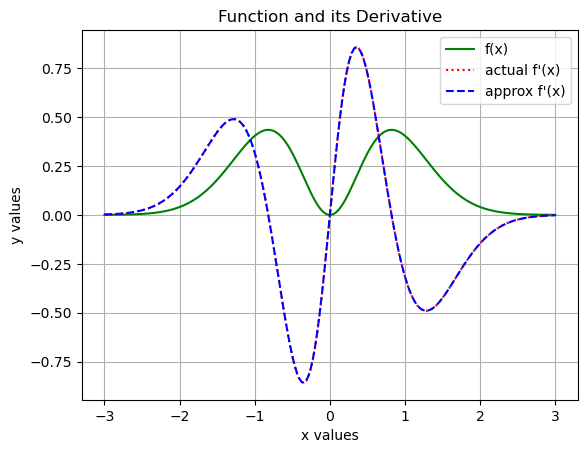

In [22]:
# Ploting f(x) and its derivative 
# Generate x values
x_values_plot = np.linspace(-3, 3, 200)  
derivative_approx = approximate_derivatives(f, x_values_plot)

plt.plot(x_values_plot, f(x_values_plot), label="f(x)", color="green")
plt.plot(x_values_plot, f_actual_derivative(x_values_plot), label="actual f'(x)", color="red", linestyle=":")
plt.plot(x_values_plot, derivative_approx, label="approx f'(x)", color="blue", linestyle="--")

plt.title("Function and its Derivative")
plt.xlabel("x values")
plt.ylabel("y values")
plt.legend()
plt.grid(True)
plt.show()

## Exercise 3

Below are the Global inflation rate from 2000 to 2024

```Python
x = array([2000, 2001, 2002, 2003, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
       2012, 2013, 2014, 2015, 2017, 2018, 2019, 2020, 2021, 2022, 2023,
       2024])
y = array([4.97, 4.64, 3.71, 3.87, 3.94, 3.94, 4.14, 6.28, 2.62, 3.6 , 4.94,
       3.98, 3.52, 3.16, 2.71, 3.23, 3.63, 3.5 , 3.25, 4.65, 8.61, 6.63,
       5.67])
```

1. Approximate the inflation rate at the year 2004
2. Approximate the inflation rate at the year 2016
3. Approximate the inflation rate at the year 2025
4. Ausing the rate you approximated for 2025, approximate the rates for the next 5 years (2026-2030)

In [16]:
x = np.array([2000, 2001, 2002, 2003, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
       2012, 2013, 2014, 2015, 2017, 2018, 2019, 2020, 2021, 2022, 2023,
       2024])
y = np.array([4.97, 4.64, 3.71, 3.87, 3.94, 3.94, 4.14, 6.28, 2.62, 3.6 , 4.94,
       3.98, 3.52, 3.16, 2.71, 3.23, 3.63, 3.5 , 3.25, 4.65, 8.61, 6.63,
       5.67])

In [17]:
# Create a linear approximation function. 
def linear_approximation_inflation(x: float, x1: int, x2: int, y1: float, y2: float) -> float:
    '''
    This calculates y-value (inflation rate) using linear approximation formula
   
    Parameters:
        x: The x-coordinate of the point to approximate.
        x1: The x-coordinate of the first known point.
        y1: The y-coordinate of the first known point.
        x2: The x-coordinate of the second known point.
        y2: The y-coordinate of the second known point.

    Returns:
        float: The approximative y-value corresponding to x.

    Example:
        >>>>> linear_approximation(2004, x[3], x[4],y[3],y[4])
        >>>>> 3.75%
    '''
    return y1 + (x-x1) * (y2-y1)/(x2-x1)

In [18]:
year_2004 = linear_approximation_inflation(2004, x[3], x[4],y[3],y[4])
print(f'Inflation rate at the year 2004 ≈ {year_2004:.2f}%')

year_2016 = linear_approximation_inflation(2016, x[14], x[15],y[14],y[15])
print(f'Inflation rate at the year 2016 ≈ {year_2016:.2f}%')

year_2025 = linear_approximation_inflation(2025, x[21], x[22],y[21],y[22])
print(f'Inflation rate at the year 2025 ≈ {year_2025:.2f}%')

x1, y1 = x[-1], y[-1]
x2, y2 = 2025, year_2025

# empty dictionary
future_rates = {}

# for loop that approximates the inflation rates according to the year it is
for year in range(2026, 2031):
    future_rates[year] = linear_approximation_inflation(year, x1, x2,y1, year_2025)

# printing the years and their respective inflation rates
print("Approximated Rates (2026-2030)")
for year, rate in future_rates.items():
    print(f"\t{year} ≈ {rate:.2f}%")

Inflation rate at the year 2004 ≈ 3.91%
Inflation rate at the year 2016 ≈ 2.97%
Inflation rate at the year 2025 ≈ 4.71%
Approximated Rates (2026-2030)
	2026 ≈ 3.75%
	2027 ≈ 2.79%
	2028 ≈ 1.83%
	2029 ≈ 0.87%
	2030 ≈ -0.09%
